# Analysis/Visualization of Cambodian Bombing and Lights Data

In [3]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import rasterio
from rasterio.mask import mask
from rasterio.plot import show
import numpy as np
import matplotlib.colors as colors
import folium
from folium.plugins import HeatMap


%matplotlib inline
%config InlineBackend.figure_format = "retina"

In [4]:
CambodiaBombingGDF = gpd.read_file('../data/CambodiaBombing.geojson')

There are no missing coordinates, and this is a Cambodia-only dataset from a reputable organization, so maybe we can just proceed with plotting without too much cleaning. 

In [5]:
CambodiaBombingGDF = CambodiaBombingGDF[['DATE','LAT', 'LON', 'LATLONKEY', 'LOAD_QTY', 'LOAD_LBS', 'CATEGORY','geometry']]

In [6]:
CambodiaBombingGDF = CambodiaBombingGDF.to_crs(epsg=4326)

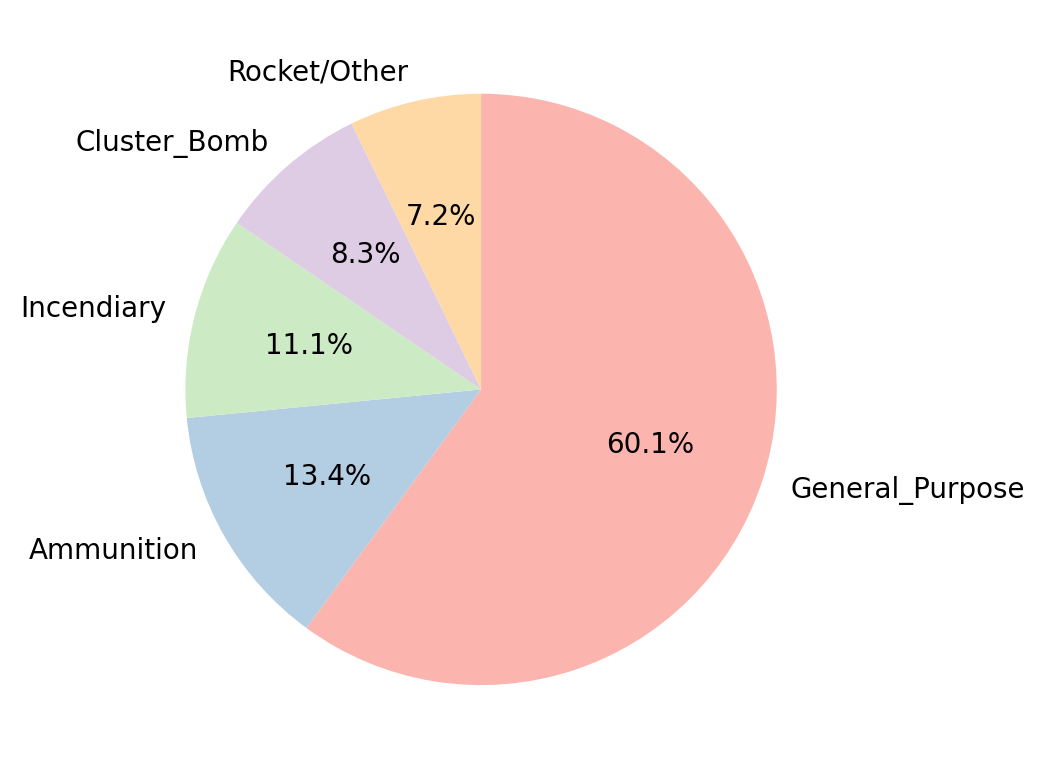

In [6]:
# Creating a pie chart to visualize the kinds of munitions used 
percentages = CambodiaBombingGDF['CATEGORY'].value_counts(normalize=True)

other = percentages[percentages < 0.05].index

CambodiaBombingGDF['Grouped'] = CambodiaBombingGDF['CATEGORY'].replace(other, 'Rocket/Other')

cmap = plt.get_cmap('Pastel1')
slice_colors = cmap(np.arange(len(percentages)))

CambodiaBombingGDF['Grouped'].value_counts().plot.pie(
    autopct='%1.1f%%', 
    startangle=90, 
    colors=slice_colors,
    counterclock=False
)
plt.ylabel('')  
plt.savefig('../figures/weaponCategoryPieChart.png')
plt.show()

In [7]:
# Summing the total weight of ordnance
CambodiaBombingGDF['LOAD_LBS'].sum()

np.float64(6175921040.0)

In [12]:
CambodiaBombingGDF['LOAD_LBS'].size

115273

# Creating an interactive bombing visualization for Cambodia

In [8]:
# Extracting lat/lon coordinates into list form to facilitate folium mapping
bombingPoints = [[point.y, point.x] for point in CambodiaBombingGDF.geometry]

meanLat = CambodiaBombingGDF.geometry.y.mean()
meanLon = CambodiaBombingGDF.geometry.x.mean()

# Creating a base map
interactiveMap = folium.Map(location=[meanLat, meanLon], zoom_start=10)

# Adding the heatmap layer
HeatMap(bombingPoints, radius=3, blur=2).add_to(interactiveMap)

interactiveMap.save('../figures/cambodiaBombingHeatmap.html')
interactiveMap

The code below crops the global night lights satellite imagery data so that it only includes Cambodia. This is importnat because the raw file is massive and unwieldy for visualization. You perform the same exact cropping for Laos (see the Laos notebook). Code was generated by Gemini. 

# Mapping night lights and bombing for Cambodia

In [10]:
# 1. Point directly to the official Natural Earth country boundaries URL
url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"

# GeoPandas handles the download and extraction entirely in memory
world_gdf = gpd.read_file(url)

# 2. Isolate Cambodia
cambodia_polygon = world_gdf[world_gdf['ADMIN'] == 'Cambodia']

if cambodia_polygon.empty:
    print("Error: Could not find Cambodia. Check the dataset column names.")
else:
    # 3. Set file paths
    global_tif_path = '../data/VNL_npp_2025_global_vcmslcfg_v2_c202604011200.median_masked.dat.tif'
    output_tif_path = '../data/cambodiaNightLights2025.tif'

    # 4. Open the global raster (metadata only)
    with rasterio.open(global_tif_path) as src:
        
        # 5. Mask the raster using the live Cambodia geometry
        out_image, out_transform = mask(src, cambodia_polygon.geometry.values, crop=True)
        out_meta = src.meta.copy()

        # 6. Update the metadata for the new, tiny bounding box
        out_meta.update({
            "driver": "GTiff",
            "height": out_image.shape[1],
            "width": out_image.shape[2],
            "transform": out_transform
        })

        # 7. Save the new Cambodia-only file to your data folder
        with rasterio.open(output_tif_path, "w", **out_meta) as dest:
            dest.write(out_image)

Clipping the global raster to Cambodia's borders...


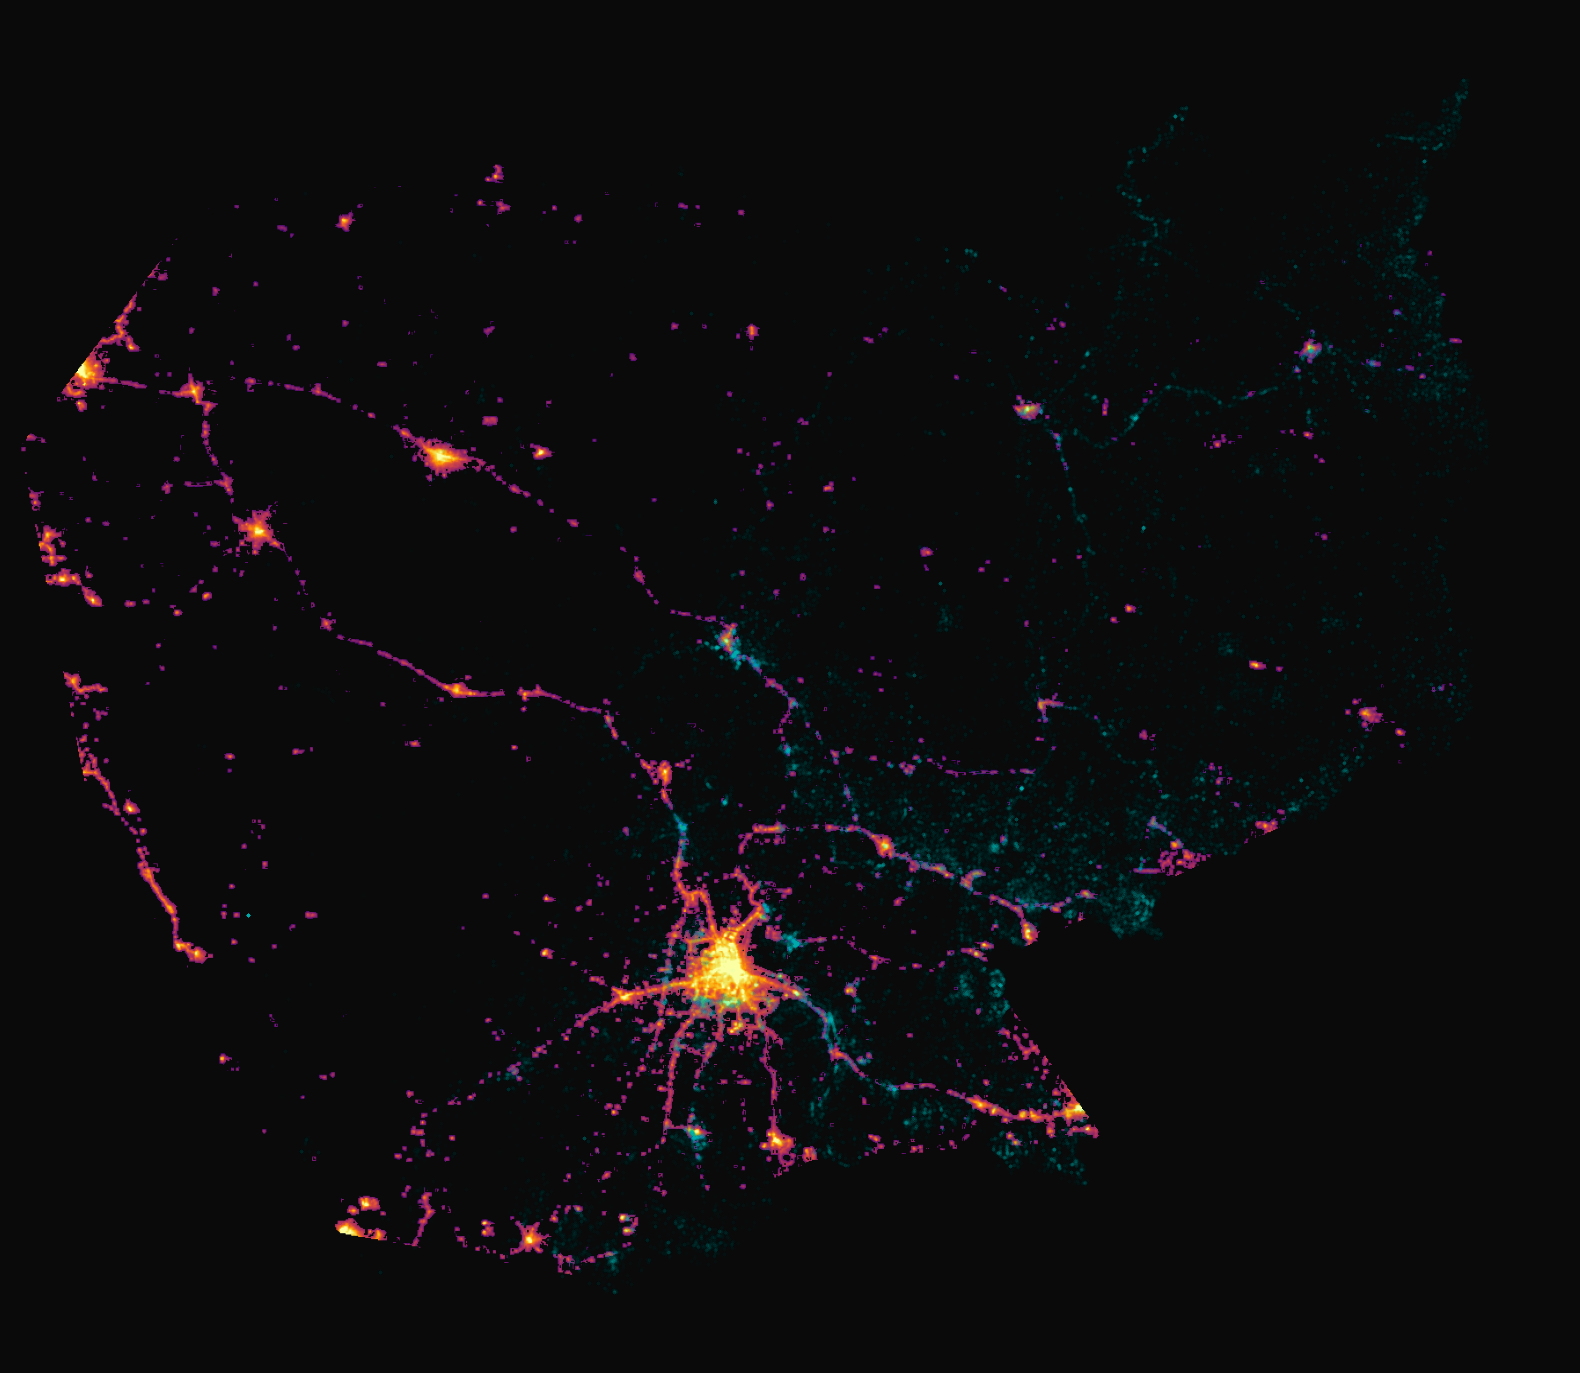

In [15]:
# Opening the night lights file that contains only those in Cambodia
src_raster = rasterio.open('../data/cambodiaNightLights2025.tif')

# Reading the first band (VIIRS data has only 1 band, but plt expects a 2D grid) 
raster_array = src_raster.read(1)

# Setting a low minimum radiance value so we can take lognorm
vmin_val = 0.1

# Setting the maximum of the lognorm to the 99th percentile of brightness, removing outliers to compress the scale 
vmax_stretch = np.percentile(raster_array[raster_array > 0], 99)

# Initializing canvas
fig, ax = plt.subplots(figsize=(8, 16), facecolor='#0a0a0a')
ax.set_facecolor('#0a0a0a')

# Displaying the night lights data as a raster on the canvas
_ = show(
    src_raster, 
    ax=ax, 
    cmap='inferno', 
    norm=colors.LogNorm(vmin=vmin_val, vmax=vmax_stretch) # from matplotlib .imshow(), which allows logarithmic transformation before assigning colors
)

# Plotting the bombing strikes over the raster data, using random sampling to reduce the saturation and make overlap easier to see 
CambodiaBombingGDF.plot(
    ax=ax, color='#00ffff', markersize=2.5, alpha=0.01, linewidth=0
)

ax.axis('off')
plt.tight_layout()
plt.savefig('../figures/cambodiaLightsPlot.png', dpi=300, bbox_inches='tight')
plt.show()

src_raster.close()